# <ins>TA-Lib All Indicators</ins>


In [4]:
from TABot import getTACombinedSignals


In [1]:
import talib
import datetime
import numpy as np
import pandas as pd
from talib import abstract
import matplotlib.pyplot as plt
from fastquant import get_crypto_data


crypto = get_crypto_data("BTC/USDT", "2023-02-01", "2023-05-22",time_resolution='15m')

df = crypto
crypto.head()

/Users/vipultanwar/.pyenv/versions/3.12.1/envs/talib/lib/python3.12/site-packages/fastquant/config.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


,open,high,low,close,volume
dt,,,,,
2023-01-31 18:30:00,23138.59,23150.72,23115.06,23144.07,1932.74166
2023-01-31 18:45:00,23143.08,23187.00,23141.26,23165.96,2112.09982
2023-01-31 19:00:00,23166.54,23188.58,23125.07,23125.91,2551.33673
2023-01-31 19:15:00,23125.91,23137.18,23087.28,23134.56,2454.33826
2023-01-31 19:30:00,23134.56,23176.55,23122.84,23173.54,2196.22545


# Defining a quick backtest function

In [2]:
def short_backtest(strategy,signals,shift,data):

    data['Signal'] = signals[strategy].shift(shift)

    data['returns'] = data.close.pct_change().fillna(0)

    data['transaction_cost'] = 0.00 * abs(data.Signal)

    data['pnl_returns'] = data.Signal*data.returns
    
    trades = min(data.Signal[data.Signal > 0].sum(),-1*data.Signal[data.Signal < 0].sum())

    sharpe = 100*(data.pnl_returns.mean()/data.pnl_returns.std()) if data.pnl_returns.std() > 0 else 0

    profit_factor = -1*data.pnl_returns[data.pnl_returns > 0].sum()/data.pnl_returns[data.pnl_returns < 0].sum()

    final_return = (data.pnl_returns + 1).cumprod()[-1]
    
    periods = len(data)
    
    return [strategy,shift,crypto.index[0].year,crypto.index[0].month,periods,trades,sharpe,profit_factor,final_return]


In [5]:
results = []

for year_ in [2022,2023]:
    for month_ in range(1,13):
        strt = datetime.date(year=year_,month=month_,day=1).strftime("%Y-%m-%d")
        end = datetime.date(year=year_,month=month_,day=28).strftime("%Y-%m-%d")
        
        crypto = get_crypto_data("BTC/USDT", strt, end,time_resolution='5m')
        signals = getTACombinedSignals(crypto,True)

        for strategy in signals.columns: 

            results.append(short_backtest(strategy,signals,1,crypto))
            results.append(short_backtest(strategy,signals,2,crypto))

df_fwd = pd.DataFrame(results,columns=['strategy','shift','year','month','periods','trades','sharpe','profit_factor','final_return'])         


In [6]:
df_fwd = pd.DataFrame(results,columns=['strategy','shift','year','month','periods','trades','sharpe','profit_factor','final_return'])    

# Averaging the performance of individual indicators

In [7]:
grp_fwd = df_fwd.groupby(['strategy','shift']).mean()

In [8]:
grp_fwd.sort_values(by='final_return',ascending=False).head(25)

,,year,month,periods,trades,sharpe,profit_factor,final_return
strategy,shift,,,,,,,
Average Price,2,2022.416667,6.5,7842.333333,3865.500000,0.905345,1.033218,1.188015
Typical Price,2,2022.416667,6.5,7842.333333,3846.625000,0.538848,1.021141,1.130245
Weighted Close Price,2,2022.416667,6.5,7842.333333,3846.833333,0.537924,1.021099,1.130131
Median Price,2,2022.416667,6.5,7842.333333,3846.833333,0.537924,1.021099,1.130131
Weighted Close Price,1,2022.416667,6.5,7842.333333,3847.416667,0.837815,1.027448,1.127457
Median Price,1,2022.416667,6.5,7842.333333,3847.416667,0.837815,1.027448,1.127457
Typical Price,1,2022.416667,6.5,7842.333333,3847.208333,0.835034,1.027358,1.127176
Average Price,1,2022.416667,6.5,7842.333333,3866.125000,0.870500,1.029334,1.126692
STOCHRSI,2,2022.416667,6.5,7842.333333,2756.500000,0.815446,1.036578,1.108617


In [9]:
crypto = get_crypto_data("BTC/USDT", '2021-05-01', '2021-10-01',time_resolution='5m')


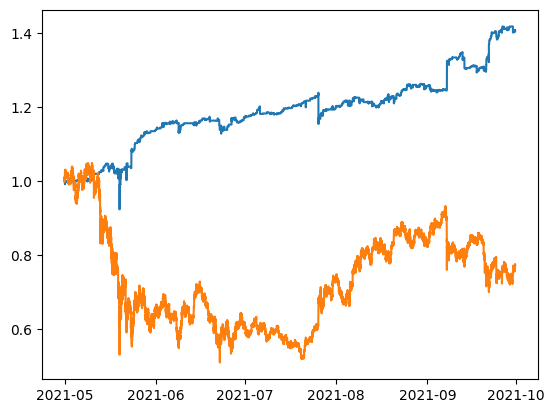

In [10]:
signals = getTACombinedSignals(crypto,True)

crypto['Signal'] = signals["ULTOSC"].shift(1)

crypto['returns'] = crypto.close.pct_change().fillna(0)

crypto['transaction_cost'] = 0.00 * abs(crypto.Signal)

crypto['pnl_returns'] = crypto.Signal*crypto.returns

plt.plot((crypto.pnl_returns + 1 ).cumprod())
plt.plot((crypto.returns + 1 ).cumprod())
    

In [294]:
results = []

for year_ in [2022,2023]:
    for month_ in range(1,13):
        strt = datetime.date(year=year_,month=month_,day=1).strftime("%Y-%m-%d")
        end = datetime.date(year=year_,month=month_,day=28).strftime("%Y-%m-%d")
        
        crypto = get_crypto_data("BTC/USDT", strt, end,time_resolution='5m')
        signals = -1*getTACombinedSignals(crypto,True)

        for strategy in signals.columns: 

            results.append(short_backtest(strategy,signals,1,crypto))
            results.append(short_backtest(strategy,signals,2,crypto))

df_rvs = pd.DataFrame(results,columns=['strategy','shift','year','month','periods','trades','sharpe','profit_factor','final_return'])         


AttributeError: 'NoneType' object has no attribute 'index'

In [295]:
df_rvs = pd.DataFrame(results,columns=['strategy','shift','year','month','periods','trades','sharpe','profit_factor','final_return'])         


In [298]:
grp_rvs = df_rvs.groupby(['strategy','shift']).mean()
grp_rvs.sort_values(by='final_return',ascending=False).head(25)

,,year,month,periods,trades,sharpe,profit_factor,final_return
strategy,shift,,,,,,,
KAMA,1,2022.333333,6.0,7836.619048,3791.380952,1.044336,1.034637,1.118475
BOP,2,2022.333333,6.0,7836.619048,2048.476190,0.626994,1.033926,1.099502
T3,1,2022.333333,6.0,7836.619048,3841.380952,0.884082,1.029204,1.096701
EMA,1,2022.333333,6.0,7836.619048,3783.476190,0.914487,1.029608,1.090237
MA,1,2022.333333,6.0,7836.619048,3796.666667,0.901626,1.029783,1.087076
T3,2,2022.333333,6.0,7836.619048,3841.000000,0.638740,1.024365,1.081034
CORREL,1,2022.333333,6.0,7836.619048,2859.142857,0.790005,1.029673,1.077842
OBV,2,2022.333333,6.0,7836.619048,0.000000,0.755541,1.042390,1.077797
TEMA,2,2022.333333,6.0,7836.619048,3829.285714,0.509289,1.020787,1.066406


In [300]:
crypto = get_crypto_data("BTC/USDT", '2021-05-01', '2021-10-01',time_resolution='5m')
signals = getTACombinedSignals(crypto,True)


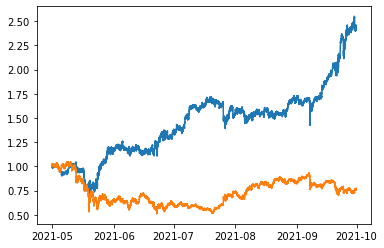

In [315]:
crypto['Signal'] = -1*signals['CORREL'].shift(1)

crypto['returns'] = crypto.close.pct_change().fillna(0)

crypto['transaction_cost'] = 0.00 * abs(crypto.Signal)

crypto['pnl_returns'] = crypto.Signal*crypto.returns

plt.plot((crypto.pnl_returns + 1 - crypto['transaction_cost'] ).cumprod())
plt.plot((crypto.returns + 1 ).cumprod())


# Experiment:
## Choose 15 forward and 15 reverse straetgies from the above lists of top 25 and create a new refined signal


In [377]:
crypto = get_crypto_data("BTC/USDT", '2021-05-01', '2021-10-01',time_resolution='5m')
signals = getTACombinedSignals(crypto,True)

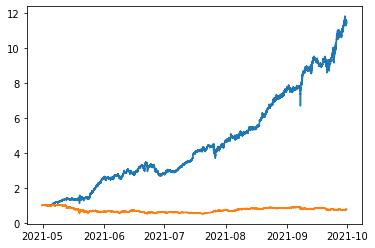

In [399]:
x = pd.Series(index=signals.index)
x = 0
for strat in grp.sort_values(by='final_return',ascending=False).head(15).index:
    x += -1*signals[strat[0]].shift(strat[1])
for strat in grp_fwd.sort_values(by='final_return',ascending=False).head(15).index:
    x += signals[strat[0]].shift(strat[1])    

crypto['Signal'] = np.where(x > 0,1,np.where(x < 0,-1,0))

crypto['returns'] = crypto.close.pct_change().fillna(0)

crypto['transaction_cost'] = 0.000 * abs(crypto.Signal)

crypto['pnl_returns'] = crypto.Signal*crypto.returns

plt.plot((crypto.pnl_returns + 1 - crypto['transaction_cost'] ).cumprod())
plt.plot((crypto.returns + 1 ).cumprod())

In [402]:
list(grp.sort_values(by='final_return',ascending=False).head(15).index)

[('KAMA', 1),
 ('BOP', 2),
 ('T3', 1),
 ('EMA', 1),
 ('MA', 1),
 ('T3', 2),
 ('CORREL', 1),
 ('OBV', 2),
 ('TEMA', 2),
 ('ADX', 1),
 ('OBV', 1),
 ('TEMA', 1),
 ('AD', 2),
 ('AD', 1),
 ('TRIMA', 1)]

In [111]:
trades = min(crypto.Signal[crypto.Signal > 0].sum(),-1*crypto.Signal[crypto.Signal < 0].sum())

sharpe = 100*(crypto.pnl_returns.mean()/crypto.pnl_returns.std())

profit_factor = -1*crypto.pnl_returns[crypto.pnl_returns > 0].sum()/crypto.pnl_returns[crypto.pnl_returns < 0].sum()

final_return = (crypto.pnl_returns + 1).cumprod()[-1]

In [9]:
def getTACombinedSignals(input_df,returnall = False):
    
    all_funcs = talib.get_functions()

    # Creating a pandas dataframe which will contain strategy signal in each column
    signals = pd.DataFrame(index = input_df.index)
    # Adding the most basic indicator which will be used in many other signals
    signals["MA"] = np.where(abstract.Function("MA")(input_df) < input_df.close,1,np.where(abstract.Function("MA")(input_df) > input_df.close,-1,0))


    # Candle Pattern Related Charting Indicators (1-61)

    for func in all_funcs:
        if ("CDL" in abstract.Function(func).info['name']):
            #print(abstract.Function(func).info['name'],abstract.Function(func).info['display_name'])
            signals[abstract.Function(func).info['display_name']] = np.where(abstract.Function(func)(input_df) > 0,1,np.where(abstract.Function(func)(input_df) < 0,-1,0))


    # Price Transform Technical Indicators (62-66)

    for func in all_funcs:
        if ("PRICE" in abstract.Function(func).info['name']):

            #print(abstract.Function(func).info['name'],abstract.Function(func).info['display_name'])
            signals[abstract.Function(func).info['display_name']] = np.where(abstract.Function(func)(input_df) > input_df['close'],1,np.where(abstract.Function(func)(input_df) < input_df['close'],-1,0))



    # Volume Based Indicator (67-69)

    ### OBV: When OBV is above its  5 day mean, buy else sell

    signals["OBV"] = np.where(abstract.Function("OBV")(input_df) > abstract.Function("OBV")(input_df).rolling(5).mean().fillna(method="bfill"),1,0)

    ### Chaikin Oscillator: When signal crosses 0 from below, buy. Vice versa for sell 

    signals["ADOSC"] = np.where(((abstract.Function("ADOSC")(input_df) >= 0)&(abstract.Function("ADOSC")(input_df).shift(1) < 0)),1,np.where(((abstract.Function("ADOSC")(input_df) < 0)&(abstract.Function("ADOSC")(input_df).shift(1) >= 0)),-1,0))

    ### Chaikin A/D Line: When signal is above its  5 day mean, buy else sell

    signals["AD"] = np.where(abstract.Function("AD")(input_df) > abstract.Function("AD")(input_df).rolling(5).mean().fillna(method="bfill"),1,0)

    # Volatility Based Indicators (70)

    ### Normalized Average True Range: Strong trend when value above 0.6. We do not consider it to be directional but supporting the directional indicators such as MACD

    ####Out of True Range, Average True Range and Normalized Average True Range: We only use the last one, rest two are inefficient versions of the same

    signals["NATR"] = np.where(abstract.Function("NATR")(input_df) > 0.6,1,0)

    signals["NATR"] = signals["NATR"]*signals["MA"]

    # Statistical Indicators (71-74)

    ### Beta: Buy when beta > 1.5 , sell when beta < - 1.5

    signals["BETA"] = np.where(abstract.Function("BETA")(input_df) > 1.5,1,np.where(abstract.Function("BETA")(input_df) < -1.5,-1,0))

    ### Correlation: Trending when Correlation > 0.85, else not trending

    signals["CORREL"] = np.where(abstract.Function("CORREL")(input_df) > 0.85,1,0)

    signals["CORREL"] = signals["CORREL"]*signals["MA"]

    ### Linear Regression: Buy/Sell when crossovers with Close price

    signals["LINEARREG"] = np.where(((input_df.close >= abstract.Function("LINEARREG")(input_df))&(input_df.close.shift(1) < abstract.Function("LINEARREG")(input_df).shift(1))),1,np.where(((input_df.close <= abstract.Function("LINEARREG")(input_df))&(input_df.close.shift(1) > abstract.Function("LINEARREG")(input_df).shift(1))),-1,0))

    ### TimeSeriesForecast: Buy/Sell when crossovers with Close price

    signals["TSF"] = np.where(((input_df.close >= abstract.Function("TSF")(input_df))&(input_df.close.shift(1) < abstract.Function("TSF")(input_df).shift(1))),1,np.where(((input_df.close <= abstract.Function("TSF")(input_df))&(input_df.close.shift(1) > abstract.Function("TSF")(input_df).shift(1))),-1,0))

    # Momentum Indicators (75-95)

    ### ADX: Trending when ADX > 25, else not trending

    signals["ADX"] = np.where(abstract.Function("ADX")(input_df) > 25,1,0)

    signals["ADX"] = signals["MA"]*signals["ADX"]

    ### ADXR: Buy when crossovers ADX < ADXR,  vice versa

    signals["ADXR"] = np.where(((abstract.Function("ADXR")(input_df) >= abstract.Function("ADX")(input_df))&(abstract.Function("ADXR")(input_df).shift(1) < abstract.Function("ADX")(input_df).shift(1))),1,np.where(((abstract.Function("ADXR")(input_df) <= abstract.Function("ADX")(input_df))&(abstract.Function("ADXR")(input_df).shift(1) > abstract.Function("ADX")(input_df).shift(1))),-1,0))

    ### APO: Buy when crossovers APO < 0,  vice versa

    signals["APO"] = np.where(((abstract.Function("APO")(input_df) >= 0)&(abstract.Function("APO")(input_df).shift(1) < 0)),1,np.where(((abstract.Function("APO")(input_df) <= 0)&(abstract.Function("APO")(input_df).shift(1) > 0)),-1,0))

    ### AROON OSC: Buy when ADX > 40 Sell when < -40


    signals["AROONOSC"] = np.where(abstract.Function("AROONOSC")(input_df) > 40,1,np.where(abstract.Function("AROONOSC")(input_df) < -40,-1,0))


    ### Balance of Power: Buy when crossovers BOP > 0 Sell when vice versa


    signals["BOP"] = np.where(((abstract.Function("BOP")(input_df) >= 0)&(abstract.Function("BOP")(input_df).shift(1) < 0)),1,np.where(((abstract.Function("BOP")(input_df) <= 0)&(abstract.Function("BOP")(input_df).shift(1) > 0)),-1,0))

    ### Commodity channel index: Buy when CCI > 100 Sell when CCI < 100


    signals["CCI"] = np.where(abstract.Function("CCI")(input_df) > 100,1,np.where(abstract.Function("CCI")(input_df) < -100,-1,0))


    ### Chande Momentum Oscillator: Buy when CMO < -50 Sell when CMO > 50


    signals["CMO"] = np.where(abstract.Function("CMO")(input_df) < -50,1,np.where(abstract.Function("CMO")(input_df) > 50,-1,0))


    ### Directional Movement Index: When DX is above its  5 period mean, buy else sell

    signals["DX"] = np.where(abstract.Function("DX")(input_df) > abstract.Function("DX")(input_df).rolling(5).mean().fillna(method="bfill"),1,np.where(abstract.Function("DX")(input_df) < abstract.Function("DX")(input_df).rolling(5).mean().fillna(method="bfill"),-1,0))

    ### MACD: Buy when crossovers MACDhist < 0 Sell when vice versa


    signals["MACD"] = np.where(((abstract.Function("MACD")(input_df).macdhist >= 0)&(abstract.Function("MACD")(input_df).macdhist.shift(1) < 0)),-1,np.where(((abstract.Function("MACD")(input_df).macdhist <= 0)&(abstract.Function("MACD")(input_df).macdhist.shift(1) > 0)),1,0))

    ### MACD EXT: Buy when crossovers MACDhist < 0 Sell when vice versa


    signals["MACDEXT"] = np.where(((abstract.Function("MACDEXT")(input_df).macdhist >= 0)&(abstract.Function("MACDEXT")(input_df).macdhist.shift(1) < 0)),-1,np.where(((abstract.Function("MACDEXT")(input_df).macdhist <= 0)&(abstract.Function("MACDEXT")(input_df).macdhist.shift(1) > 0)),1,0))

    ### MACD FIX: Buy when crossovers MACDhist < 0 Sell when vice versa


    signals["MACDFIX"] = np.where(((abstract.Function("MACDFIX")(input_df).macdhist >= 0)&(abstract.Function("MACDFIX")(input_df).macdhist.shift(1) < 0)),-1,np.where(((abstract.Function("MACDFIX")(input_df).macdhist <= 0)&(abstract.Function("MACDFIX")(input_df).macdhist.shift(1) > 0)),1,0))

    ### Money Flow index: Buy when MFI < 30  Sell when MFI > 80 (Overbought and oversold)


    signals["MFI"] = np.where(abstract.Function("MFI")(input_df) < 30,1,np.where(abstract.Function("MFI")(input_df) > 80,-1,0))


    ### Momentum Indicator: Buy when MOM > 100  Sell when MOM < -100 

    signals["MOM"] = np.where(abstract.Function("MOM")(input_df) > 100,1,np.where(abstract.Function("MOM")(input_df) < -100,-1,0))


    ### Rate of Change Indicator: Buy when ROC > 0.25  Sell when ROC < -0.25 

    signals["ROC"] = np.where(abstract.Function("ROC")(input_df) > 0.25,1,np.where(abstract.Function("ROC")(input_df) < -0.25,-1,0))


    ### Relative Strength Index: Buy when RSI < 30  Sell when RSI > 70 (Overbought and oversold)


    signals["RSI"] = np.where(abstract.Function("RSI")(input_df) < 30,1,np.where(abstract.Function("RSI")(input_df) > 70,-1,0))


    ### Stochastic: Buy when STOCH.slowk < 20  Sell when STOCH.slowk > 80 (Overbought and oversold)


    signals["STOCH"] = np.where(abstract.Function("STOCH")(input_df).slowk < 20,1,np.where(abstract.Function("STOCH")(input_df).slowk > 80,-1,0))


    ### Stochastic Fast: Buy when STOCH.slowk < 20  Sell when STOCH.slowk > 80 (Overbought and oversold)


    signals["STOCHF"] = np.where(abstract.Function("STOCHF")(input_df).fastk < 20,1,np.where(abstract.Function("STOCHF")(input_df).fastk > 80,-1,0))


    ### Stochastic RSI: Buy when STOCH.fastk < 20  Sell when STOCH.fastk > 80 (Overbought and oversold)


    signals["STOCHRSI"] = np.where(abstract.Function("STOCHRSI")(input_df).fastk < 20,1,np.where(abstract.Function("STOCHRSI")(input_df).fastk > 80,-1,0))


    ### Triple Exp Avg: Buy when TRIX crossovers < 0  Sell when vice versa


    signals["TRIX"] = np.where(((abstract.Function("TRIX")(input_df) >= 0)&(abstract.Function("TRIX")(input_df).shift(1) < 0)),-1,np.where(((abstract.Function("TRIX")(input_df) <= 0)&(abstract.Function("TRIX")(input_df).shift(1) > 0)),1,0))

    ### Ultimate Oscillator: Buy when ULTOSC < 30  Sell when ULTOSC > 70 (Overbought and oversold)


    signals["ULTOSC"] = np.where(abstract.Function("ULTOSC")(input_df) < 30,1,np.where(abstract.Function("ULTOSC")(input_df) > 70,-1,0))


    ### Williams %R: Buy when WILLR < 30  Sell when WILLR > 70 (Overbought and oversold)


    signals["WILLR"] = np.where(abstract.Function("WILLR")(input_df) < -80,1,np.where(abstract.Function("WILLR")(input_df) > -20,-1,0))


    # Overlap Studies (96-108)

    ### Moving Averages: Buy when price > MA else sell 

    signals["MA"] = np.where(abstract.Function("MA")(input_df) < input_df.close,1,np.where(abstract.Function("MA")(input_df) > input_df.close,-1,0))


    ### Exponential Moving Averages: Buy when price > EMA else sell 

    signals["EMA"] = np.where(abstract.Function("EMA")(input_df) < input_df.close,1,np.where(abstract.Function("EMA")(input_df) > input_df.close,-1,0))


    ### Double Exponential Moving Averages: Buy when price > DEMA else sell 

    signals["DEMA"] = np.where(abstract.Function("DEMA")(input_df) < input_df.close,1,np.where(abstract.Function("DEMA")(input_df) > input_df.close,-1,0))


    ### Kaufman Adaptive Moving Average: Buy when price > KAMA else sell 

    signals["KAMA"] = np.where(abstract.Function("KAMA")(input_df) < input_df.close,1,np.where(abstract.Function("KAMA")(input_df) > input_df.close,-1,0))


    ### MESA Adaptive Moving Average: Buy when fama > mama else sell 

    signals["MAMA"] = np.where(abstract.Function("MAMA")(input_df).mama > abstract.Function("MAMA")(input_df).fama,1,np.where(abstract.Function("MAMA")(input_df).mama < abstract.Function("MAMA")(input_df).fama,-1,0))


    ### MIDPOINT: When MP is above its  5 period mean, buy else sell

    signals["MIDPOINT"] = np.where(abstract.Function("MIDPOINT")(input_df) > abstract.Function("MIDPOINT")(input_df).rolling(5).mean().fillna(method="bfill"),1,np.where(abstract.Function("MIDPOINT")(input_df) < abstract.Function("MIDPOINT")(input_df).rolling(5).mean().fillna(method="bfill"),-1,0))

    ### MIDPRICE: When MPX is above its  5 period mean, buy else sell

    signals["MIDPRICE"] = np.where(abstract.Function("MIDPRICE")(input_df) > abstract.Function("MIDPRICE")(input_df).rolling(5).mean().fillna(method="bfill"),1,np.where(abstract.Function("MIDPRICE")(input_df) < abstract.Function("MIDPRICE")(input_df).rolling(5).mean().fillna(method="bfill"),-1,0))

    ### Parabolic SAR: Buy/Sell when crossovers with Close price

    signals["SAR"] = -1*np.where(((input_df.close >= abstract.Function("SAR")(input_df))&(input_df.close.shift(1) < abstract.Function("SAR")(input_df).shift(1))),1,np.where(((input_df.close <= abstract.Function("SAR")(input_df))&(input_df.close.shift(1) > abstract.Function("SAR")(input_df).shift(1))),-1,0))

    ### Parabolic SAR Extended: Buy when >0 else sell 

    signals["SAREXT"] = -1*np.where(((abstract.Function("SAREXT")(input_df) >= 0)&(abstract.Function("SAREXT")(input_df).shift(1) < 0)),1,np.where(((abstract.Function("SAREXT")(input_df) <= 0)&(abstract.Function("SAREXT")(input_df).shift(1) > 0)),-1,0))

    ### Triple Exponential Moving Average: Buy when price > T3 else sell 

    signals["T3"] = np.where(abstract.Function("T3")(input_df) < input_df.close,1,np.where(abstract.Function("T3")(input_df) > input_df.close,-1,0))


    ### Triple Exponential Moving Average: Buy when price > TEMA else sell 

    signals["TEMA"] = np.where(abstract.Function("TEMA")(input_df) < input_df.close,1,np.where(abstract.Function("TEMA")(input_df) > input_df.close,-1,0))


    ### Triangular Moving Average: Buy when price > TRIMA else sell 

    signals["TRIMA"] = np.where(abstract.Function("TRIMA")(input_df) < input_df.close,1,np.where(abstract.Function("TRIMA")(input_df) > input_df.close,-1,0))


    ### Weighted Moving Average: Buy when price > WMA else sell 

    signals["WMA"] = np.where(abstract.Function("WMA")(input_df) < input_df.close,1,np.where(abstract.Function("WMA")(input_df) > input_df.close,-1,0))


    # Math Operators (109)


    ### Max and Min: Buy when price = Min, sell when price = Max

    signals["MINMAX"] = np.where(abstract.Function("MIN")(input_df) == input_df.close,1,np.where(abstract.Function("MAX")(input_df) == input_df.close,-1,0))


    # Hilbert Transform Cycle Indicators (110-111)


    ## Dominant Cycle Period: Trend confirmed when HT_DCPERIOD > 25

    signals["HT_DCPERIOD"] = np.where(abstract.Function("HT_DCPERIOD")(input_df) > 25,1,0)

    signals["HT_DCPERIOD"] = signals["MA"]*signals["HT_DCPERIOD"]

    ## Trend vs Cycle Mode: Use trending strategy (MA) when HT_TRENDMODE = 1 else Use cyclic strategy (RSI)

    signals["HT_TRENDMODE"] = np.where(abstract.Function("HT_TRENDMODE")(input_df) ==1,signals["MA"],signals["RSI"])

    if returnall:
        return signals
    else:
        return signals.iloc[-1]

In [56]:
for group, funcs in talib.get_function_groups().items():
    print(group)
    print('-----------------------------------------')
    for func in funcs:
        f = abstract.Function(func)
        print('{} - {}'.format(func, f.info['display_name']))
    print()

Cycle Indicators
-----------------------------------------
HT_DCPERIOD - Hilbert Transform - Dominant Cycle Period
HT_DCPHASE - Hilbert Transform - Dominant Cycle Phase
HT_PHASOR - Hilbert Transform - Phasor Components
HT_SINE - Hilbert Transform - SineWave
HT_TRENDMODE - Hilbert Transform - Trend vs Cycle Mode

Math Operators
-----------------------------------------
ADD - Vector Arithmetic Add
DIV - Vector Arithmetic Div
MAX - Highest value over a specified period
MAXINDEX - Index of highest value over a specified period
MIN - Lowest value over a specified period
MININDEX - Index of lowest value over a specified period
MINMAX - Lowest and highest values over a specified period
MINMAXINDEX - Indexes of lowest and highest values over a specified period
MULT - Vector Arithmetic Mult
SUB - Vector Arithmetic Substraction
SUM - Summation

Math Transform
-----------------------------------------
ACOS - Vector Trigonometric ACos
ASIN - Vector Trigonometric ASin
ATAN - Vector Trigonometric AT